# Premier League 26/27 - Exploratory Data Analysis (EDA)
This notebook explores the cleaned player performance dataset to uncover trends, top performers, and metric distributions.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

## 1. Load Cleaned Dataset

In [2]:
df = pd.read_csv('../data/processed/players_cleaned.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (653, 13)


,first_name,second_name,team_name,position,now_cost,minutes,goals_scored,assists,clean_sheets,expected_goals,expected_assists,total_points,market_value_m
0,David,Raya Martín,Arsenal,Goalkeeper,60,180,0,0,2,0.00,0.00,12,6.0
1,Kepa,Arrizabalaga Revuelta,Arsenal,Goalkeeper,49,0,0,0,0,0.00,0.00,0,4.9
2,Illan,Meslier,Arsenal,Goalkeeper,49,0,0,0,0,0.00,0.00,0,4.9
3,Gabriel,dos Santos Magalhães,Arsenal,Defender,80,180,0,0,2,0.18,0.03,13,8.0
4,Jurriën,Timber,Arsenal,Defender,65,0,0,0,0,0.00,0.00,0,6.5


## 2. Statistical Summary

In [3]:
df.describe()

,now_cost,minutes,goals_scored,assists,clean_sheets,expected_goals,expected_assists,total_points,market_value_m
count,653.000000,653.000000,653.000000,653.000000,653.000000,653.000000,653.000000,653.000000,653.000000
mean,51.295559,84.497703,0.111792,0.110260,0.287902,0.137443,0.078836,3.961715,5.129556
std,9.777898,102.402694,0.397151,0.387815,0.572738,0.345010,0.170445,5.639209,0.977790
min,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-2.000000,4.000000
25%,45.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.500000
50%,50.000000,22.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,5.000000
75%,55.000000,175.000000,0.000000,0.000000,0.000000,0.080000,0.060000,6.000000,5.500000
max,155.000000,270.000000,3.000000,3.000000,3.000000,2.460000,1.350000,28.000000,15.500000


## 3. Position-wise Performance breakdown
Let's see how total points and goal contributions differ across player positions (Forward, Midfielder, Defender, Goalkeeper).

In [4]:
position_summary = df.groupby('position')[['goals_scored', 'assists', 'total_points', 'market_value_m']].mean().reset_index()
position_summary.sort_values(by='total_points', ascending=False)

,position,goals_scored,assists,total_points,market_value_m
0,Defender,0.060748,0.065421,4.429907,4.660280
3,Midfielder,0.151724,0.155172,4.072414,5.463448
1,Forward,0.205128,0.166667,3.461538,5.733333
2,Goalkeeper,0.000000,0.000000,2.647887,4.516901


## 4. Correlation Heatmap
Let's check how metrics like market value, expected goals, and total points correlate with each other.

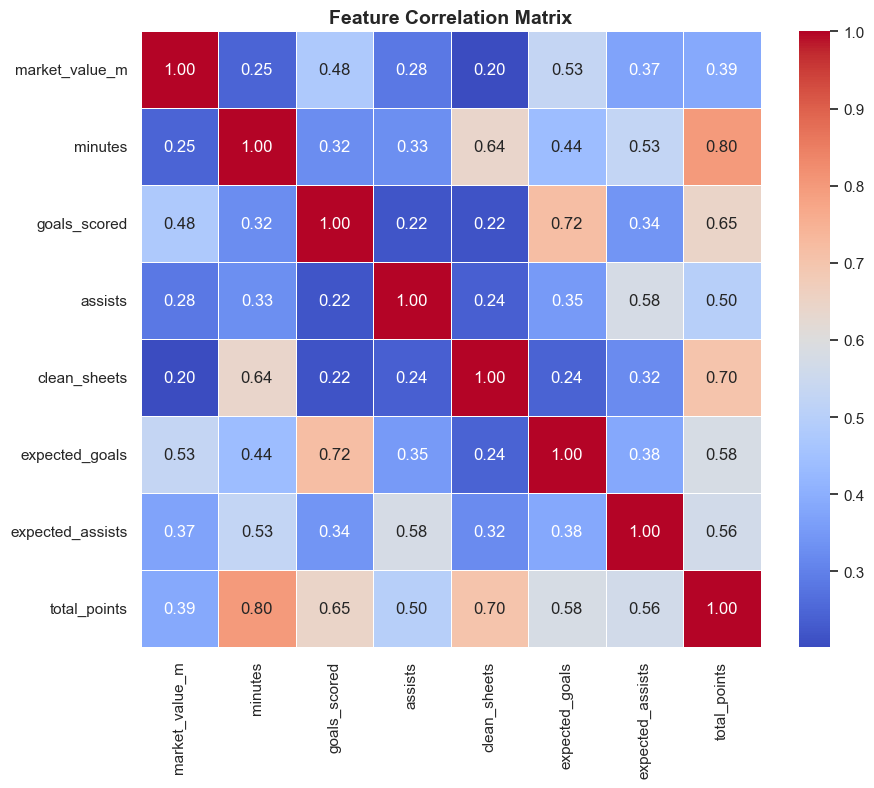

In [5]:
numeric_cols = ['market_value_m', 'minutes', 'goals_scored', 'assists', 'clean_sheets', 'expected_goals', 'expected_assists', 'total_points']
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.show()